In [1]:
import pandas as pd
from pathlib import Path

pred_path = Path("../results/enron/predictions.csv")
df = pd.read_csv(pred_path)
df.head()


,id,label,text,prediction
0,1,ham,Subject: elm course offering\neffective negoti...,ham
1,2,ham,Subject: start date : 1 / 10 / 02 ; hourahead ...,ham
2,3,ham,Subject: schedule crawler : hourahead failure\...,ham
3,4,ham,Subject: start date : 12 / 26 / 01 ; hourahead...,ham
4,5,ham,Subject: start date : 1 / 12 / 02 ; hourahead ...,ham


In [2]:
df.info()
df.describe(include='object')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33547 entries, 0 to 33546
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          33547 non-null  int64 
 1   label       33547 non-null  object
 2   text        33547 non-null  object
 3   prediction  33547 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.0+ MB


,label,text,prediction
count,33547,33547,33547
unique,2,30325,2
top,spam,Subject:,ham
freq,17076,51,16859


In [3]:
# Check for missing or duplicate ids
print("Missing labels:", df['label'].isna().sum())
print("Missing predictions:", df['prediction'].isna().sum())
print("Duplicate ids:", df['id'].duplicated().sum())

# Count distribution
print("\nLabel distribution:")
print(df['label'].value_counts())
print("\nPrediction distribution:")
print(df['prediction'].value_counts())


Missing labels: 0
Missing predictions: 0
Duplicate ids: 0

Label distribution:
label
spam    17076
ham     16471
Name: count, dtype: int64

Prediction distribution:
prediction
ham     16859
spam    16688
Name: count, dtype: int64


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, confusion_matrix, ConfusionMatrixDisplay
)
from pathlib import Path

# === Paths ===
pred_path = Path("../results/enron/predictions.csv")
MODEL_NAME = "gpt-5-mini"

# === Load combined CSV ===
df = pd.read_csv(pred_path)
df.columns = [c.strip().lower() for c in df.columns]

# Ensure normalization
df["label"] = df["label"].str.strip().str.lower()
df["prediction"] = df["prediction"].str.strip().str.lower()

# Filter valid rows
df = df[df["label"].isin(["ham", "spam"])]
df = df[df["prediction"].isin(["ham", "spam"])]

print(f"✅ {MODEL_NAME} — {len(df)} samples loaded")
df.head()


✅ gpt-5-mini — 33547 samples loaded


,id,label,text,prediction
0,1,ham,Subject: elm course offering\neffective negoti...,ham
1,2,ham,Subject: start date : 1 / 10 / 02 ; hourahead ...,ham
2,3,ham,Subject: schedule crawler : hourahead failure\...,ham
3,4,ham,Subject: start date : 12 / 26 / 01 ; hourahead...,ham
4,5,ham,Subject: start date : 1 / 12 / 02 ; hourahead ...,ham


In [7]:
y_true = df["label"]
y_pred = df["prediction"]

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, pos_label="spam", zero_division=0)
rec  = recall_score(y_true, y_pred, pos_label="spam", zero_division=0)
f1   = f1_score(y_true, y_pred, pos_label="spam", zero_division=0)
mcc  = matthews_corrcoef(y_true, y_pred)

cm = confusion_matrix(y_true, y_pred, labels=["ham", "spam"])
tn, fp, fn, tp = cm.ravel()
bh = fp / (fp + tn) if (fp + tn) > 0 else 0

results = {
    "model": MODEL_NAME,
    "samples": len(df),
    "accuracy": acc * 100,
    "precision": prec * 100,
    "recall": rec * 100,
    "f1": f1 * 100,
    "bh": bh * 100,
    "mcc": mcc * 100,
}

df_results = pd.DataFrame([results]).round(2)
display(df_results)


,model,samples,accuracy,precision,recall,f1,bh,mcc
0,gpt-5-mini,33547,97.73,98.88,96.63,97.74,1.14,95.48


In [8]:
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#0e0e0e",
    "figure.facecolor": "#0e0e0e",
    "text.color": "#e0e0e0",
    "axes.labelcolor": "#e0e0e0",
    "xtick.color": "#e0e0e0",
    "ytick.color": "#e0e0e0",
    "grid.color": "#303030"
})


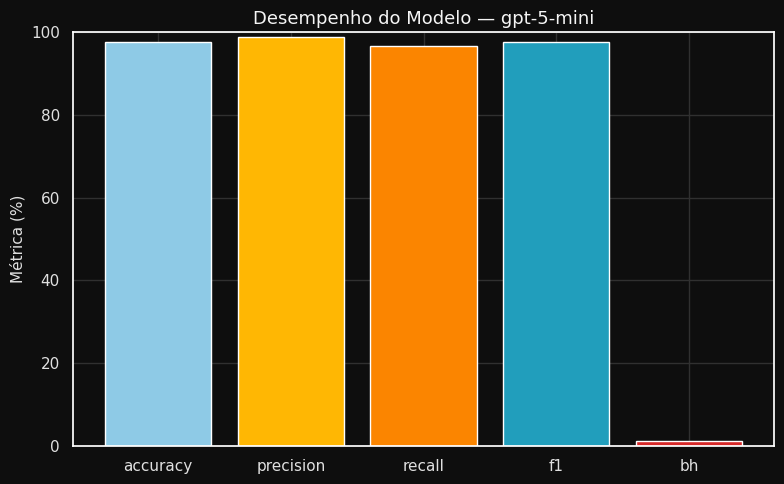

In [9]:
plt.figure(figsize=(8,5))
palette = {
    "accuracy":"#8ecae6",
    "precision":"#ffb703",
    "recall":"#fb8500",
    "f1":"#219ebc",
    "bh":"#d62828"
}

metrics = ["accuracy","precision","recall","f1","bh"]
values = [results[m] for m in metrics]

plt.bar(metrics, values, color=[palette[m] for m in metrics])
plt.title(f"Desempenho do Modelo — {MODEL_NAME}", fontsize=13, color="#f5f5f5")
plt.ylabel("Métrica (%)", fontsize=11)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


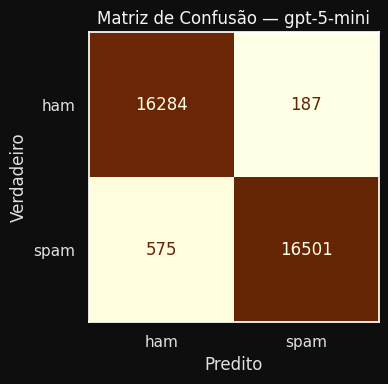

In [10]:
fig, ax = plt.subplots(figsize=(4.5,4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["ham", "spam"])
disp.plot(ax=ax, cmap="YlOrBr", colorbar=False)

ax.set_title(f"Matriz de Confusão — {MODEL_NAME}", color="#f5f5f5")
ax.set_xlabel("Predito", color="#e0e0e0")
ax.set_ylabel("Verdadeiro", color="#e0e0e0")
ax.tick_params(colors="#e0e0e0")
ax.grid(False)
fig.patch.set_facecolor("#0e0e0e")
ax.set_facecolor("#0e0e0e")
plt.tight_layout()
plt.show()


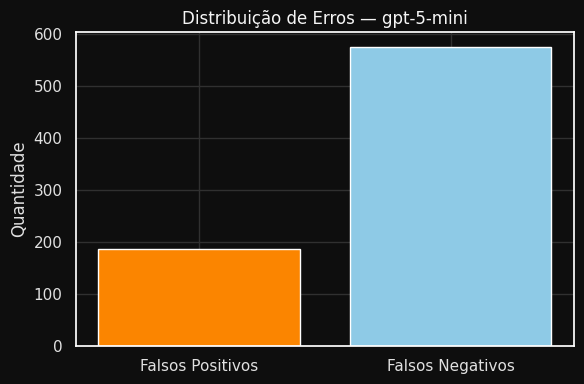

In [11]:
fp = np.sum((df["label"] == "ham") & (df["prediction"] == "spam"))
fn = np.sum((df["label"] == "spam") & (df["prediction"] == "ham"))

plt.figure(figsize=(6,4))
plt.bar(["Falsos Positivos", "Falsos Negativos"], [fp, fn],
        color=["#fb8500", "#8ecae6"])
plt.title(f"Distribuição de Erros — {MODEL_NAME}", color="#f5f5f5")
plt.ylabel("Quantidade", color="#e0e0e0")
plt.xticks(color="#e0e0e0")
plt.yticks(color="#e0e0e0")
plt.gcf().patch.set_facecolor("#0e0e0e")
plt.gca().set_facecolor("#0e0e0e")
plt.tight_layout()
plt.show()


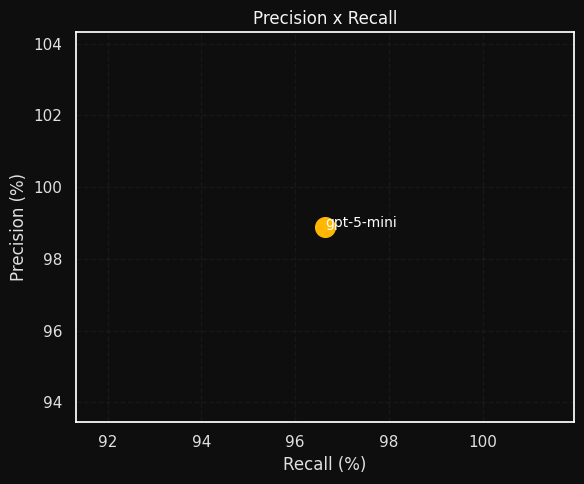

In [12]:
plt.figure(figsize=(6,5))
plt.scatter(results["recall"], results["precision"], s=200, color="#ffb703")
plt.text(results["recall"], results["precision"], MODEL_NAME, fontsize=10, color="white")

plt.xlabel("Recall (%)")
plt.ylabel("Precision (%)")
plt.title("Precision x Recall", color="#f5f5f5")
plt.grid(True, linestyle="--", alpha=0.3)
plt.gcf().patch.set_facecolor("#0e0e0e")
plt.gca().set_facecolor("#0e0e0e")
plt.tight_layout()
plt.show()
